In [118]:
import matplotlib.pyplot as plt
import sympy as sp

# Transformada de Laplace

Si $f(t)$ es una función definida en $[0,\infty[$ con $t$ y $f$ reales, entonces la transformada de Laplace de la función $f$ se denota por $\mathcal{L}\lbrace f(t) \rbrace = F(s)$ y se define como la integral
$$ \mathcal{L}\lbrace f(t) \rbrace = F(s) = \int_{0}^{\infty} f(t) e^{-st} dt $$
siempre que la anterior sea convergente.

Como la transformada de Laplace es una integral, mediante Pyton podríamos querer calcularla directamente, eso podemos hacerlo mediante la función `integrate`. Para ello resolvamos el siguiente ejemplo:

### Ejemplo 01

Integrando, calcular 
$$\mathcal{L}\lbrace t^3 \rbrace = \displaystyle\int_{0}^{\infty} t^3 e^{-st } dt.$$

Para resolver el ejemplo, primero debemos importar las librerias que podremos necesitar:

In [119]:
# definimos algunos objetos con los que queremos trabajar.
                        #, real = True, positive = True
t, s = sp.symbols('t, s', real = True, positive = True) #símbolos
a = sp.symbols('a', real=True, positive=True) #símbolo real positivo

#definimos la función con la que queremos trabajar
f = t**3
f #la imprimimos, para verificar

t**3

In [120]:

            #funcion    #variables    #límites de integración
sp.integrate(f*sp.exp(-s*t), (t, 0, sp.oo))

6/s**4

Para poder trabajar de forma más fluida, `Sympy` tiene una función llamada `laplace_transform` que hace esto de manera eficiente y que también retorna condiciones de convergencia de la integral:

## `laplace_transform( )`

### Ejemplo 02

Usemos la función `laplace_transform( )` para calcular la misma Transformada de Laplace anterior:

In [121]:
from sympy import laplace_transform


                    #funcion #tranforma la funcion que antes dependia de t, a que dependa de s
sp.laplace_transform(f, t, s)

(6/s**4, 0, True)

Si deseamos solo la función sin importar las condiciones de convergencia, agregamos `noconds=True`:

In [122]:
                                #si queremos que nos de la transformada sin basura
sp.laplace_transform(f, t, s, noconds=True)

6/s**4

Python también tiene la función

## `inverse_laplace_transform( )`

### Ejemplo 03

Calcule la transformada inversa de la función $\frac{6}{s^4}$.

Para ello definimos $F$ en base al cálculo anterior:

In [123]:
                        
F = sp.laplace_transform(f, t, s, noconds=True)
F

6/s**4

Ahora calculamos la inversa solicitada:

In [124]:
#revisar las restricciones de positivos y reales
                            #ahora es de s a t
sp.inverse_laplace_transform(F, s, t)

t**3

## ¿Qué es $\theta$?

Es la función paso unitario, también conocida como la función de Heaviside. Esta función la encontraremos a menudo al trabajar con la inversa de Laplace. Mediante Sympy la podemos llamar como:

In [125]:
#funcion de salto
sp.Heaviside(t)

1

Y gráficamente es:

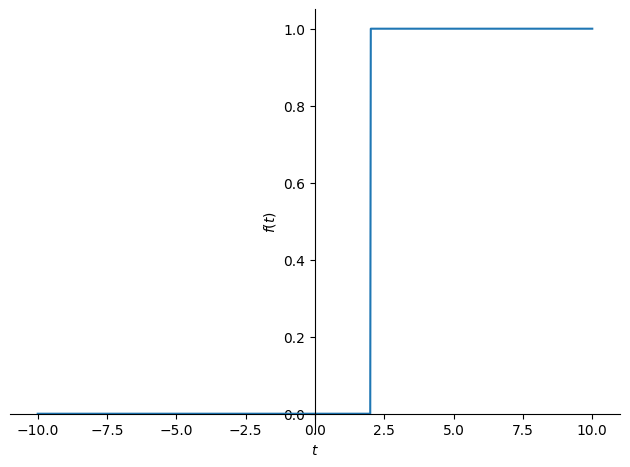

In [126]:
#grafico de funcion de salto
sp.plot(sp.Heaviside(t - 2))

### Ejemplo 04

Calcule la Transformada de Laplace de $\sin(t) $.

Definimos primero la función $ f(t) = \sin(t) $ en `SymPy`. Luego usamos la función `laplace_transform` para encontrar su transformada.

Recordemos que la Transformada de Laplace de $ \sin(at) $ es:

$$ \mathcal{L}\lbrace \sin(at) \rbrace = \frac{a}{s^2 + a^2} $$

In [127]:
f_sin = sp.sin(a*t)
laplace_transform(f_sin, t, s, noconds=True)

a/(a**2 + s**2)

## Ejercicios:

### Ejercicio 01

Calcular transformada de Laplace de $f(t)=\cos t$ y de $g(t)=\cosh(2t)$

In [128]:
f = sp.cos(t)
g = sp.cosh(2*t)

In [129]:
laplace_f = sp.laplace_transform(f, t, s, noconds=True)
laplace_g = sp.laplace_transform(g, t, s, noconds=True)

In [130]:
laplace_f

s/(s**2 + 1)

In [131]:
laplace_g

s/(s**2 - 4)

### Ejericicio 02
Calcular la transformada inversa de Laplace $F(s)= \dfrac{1}{s}$

In [132]:
f = 1/s
inversa_3 = sp.inverse_laplace_transform(f, s, t)
inversa_3

1

### Ejericicio 03

Calcular transformada de Laplace de $f(t)=e^{-\alpha t}$ con $\alpha \in \mathbb{R}^+$. Utilice su resultado para calcular su inversa.

In [133]:
# Definimos el símbolo alpha
alpha = sp.symbols('alpha', real=True, positive=True)

# Definimos la función f(t) = e^(-alpha * t)
f_exp = sp.exp(-alpha * t)

# Calculamos la transformada de Laplace de f(t)
laplace_f_exp = sp.laplace_transform(f_exp, t, s, noconds=True)
laplace_f_exp

1/(alpha + s)

In [134]:
funcion_3 = 1/(alpha + s) 
inversa_3 = sp.inverse_laplace_transform(funcion_3, s, t)
inversa_3


exp(-alpha*t)

### Ejericicio 04

Calcular la transformada de Laplace de 
$$ g(t) = \cos At + t\sin Bt, $$
con $A,B \in \mathbb{R}$

In [138]:
# Definimos los símbolos A y B
A, B = sp.symbols('A B', real=True)

# Definimos la función g(t) = cos(At) + t*sin(Bt)
g_t = sp.cos(A*t) + t*sp.sin(B*t)

# Calculamos la transformada de Laplace de g(t)
laplace_g_t = sp.laplace_transform(g_t, t, s, noconds=True)
laplace_g_t

s/(A**2 + s**2) + I/(2*(I*B + s)**2) - I/(2*(-I*B + s)**2)

### Ejericicio 05
Suponga que $f:[0,\infty[ \to \mathbb{R}$ es continua por partes y de orden exponencial (posee transformada de Laplace). Verifique que:

$$\mathcal{L}\lbrace t f(t) \rbrace = -\dfrac{d}{ds}  \mathcal{L} \lbrace f(t) \rbrace  $$

para una función $f$ a elección.

In [136]:
# Definimos la función f(t) = cos(t)
f_t = sp.cos(t)

# Calculamos la transformada de Laplace de f(t)
F_s = sp.laplace_transform(f_t, t, s, noconds=True)

# Calculamos la derivada de F(s) con respecto a s
dF_ds = sp.diff(F_s, s)

# Calculamos la transformada de Laplace de t * f(t)
laplace_t_f_t = sp.laplace_transform(t * f_t, t, s, noconds=True)

# Verificamos la propiedad
verificacion = -dF_ds == laplace_t_f_t
verificacion

False

### Ejericicio 06

Calcular la transformada de Laplace inversa de 
$$ H(s) = \dfrac{(s+1)(s-1)}{(s+4)^2} $$

In [142]:
# Definimos la función H(s)
H_s = (s + 1) * (s - 1) / (s + 4)**2

# Calculamos la transformada inversa de Laplace de H(s)
inversa_H_s = sp.inverse_laplace_transform(H_s, s, t)
inversa_H_s

#sp.apart(H_s)
#sp.inverse_laplace_transform(sp.apart(H_s), s, t, noconds=True)

15*t*exp(-4*t) - 8*exp(-4*t)